# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [ ]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

Dataset loaded: 119,390 bookings, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

In [ ]:
# ============================================================
# CLIENT C: Online Shoppers Purchase Intention
# ============================================================
# An e-commerce company wants to predict which website visitors
# will actually complete a purchase.
# Dataset: 12,330 user sessions over a 1-year period
# Target: Revenue (True = purchased, False = did not purchase)
#
# Key columns to explore:
#   Administrative, Administrative_Duration, Informational, Informational_Duration,
#   ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues,
#   SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType,
#   VisitorType, Weekend
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=468)  # Online Shoppers Purchasing Intention
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} sessions, {df.shape[1]} columns")
df.head()

---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [ ]:
# Shape of the dataset (rows and columns)
df.shape
# Data types for each column
df.dtypes
# Check for missing values in each column
df.isnull().sum()
# Distribution of the target variable (cancellations)
df["is_canceled"].value_counts()
# Cancellation rate (percentage of bookings canceled)
df["is_canceled"].mean()
# Summary statistics for key numerical columns
df[["lead_time","adr","adults","children","stays_in_week_nights","stays_in_weekend_nights"]].describe()


,lead_time,adr,adults,children,stays_in_week_nights,stays_in_weekend_nights
count,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000
mean,104.011416,101.831122,1.856403,0.103890,2.500302,0.927599
std,106.863097,50.535790,0.579261,0.398561,1.908286,0.998613
min,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,69.290000,2.000000,0.000000,1.000000,0.000000
50%,69.000000,94.575000,2.000000,0.000000,2.000000,1.000000
75%,160.000000,126.000000,2.000000,0.000000,3.000000,2.000000
max,737.000000,5400.000000,55.000000,10.000000,50.000000,19.000000


**Client Briefing — The Situation:**

The dataset contains 119,390 hotel bookings across 32 variables.About 37% of bookings are canceled, meaning cancellations are fairly common and represent an operational challenge for the hotel. Most variables appear complete, although a few columns contain missing values, and there are some unusual entries such as negative room rates or very large guest counts that may need to be cleaned. The dataset is large and useful, but some minor data quality issues need to be addressed before building predictive models.



---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

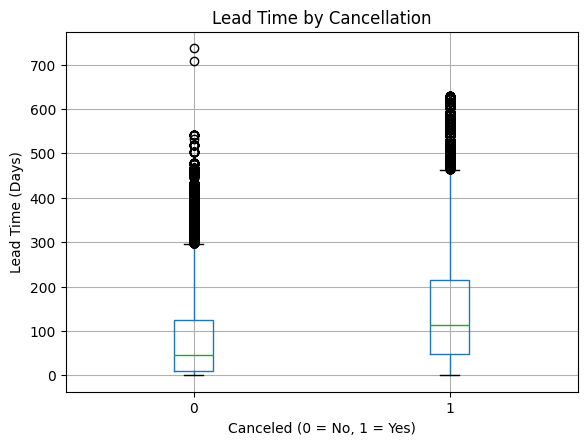

In [ ]:
# Discovery Angle 1: Booking Lead Time and Cancellations
df.groupby("is_canceled")["lead_time"].mean()
import matplotlib.pyplot as plt

df.boxplot(column="lead_time", by="is_canceled")

plt.title("Lead Time by Cancellation")
plt.suptitle("")
plt.xlabel("Canceled (0 = No, 1 = Yes)")
plt.ylabel("Lead Time (Days)")

plt.show()

**Finding 1:**

Bookings that are made further in advance tend to cancel more often than those made closer to the stay date. This suggests that guests who book many months ahead may be more likely to change their plans later. Encouraging confirmations or deposits for bookings made far in advance could help reduce cancellations.



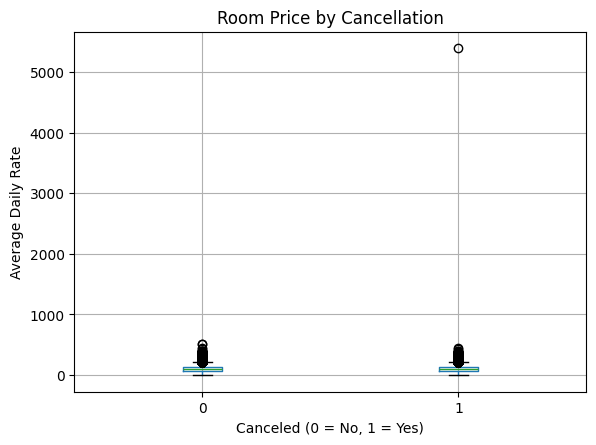

In [25]:
# Discovery Angle 2:Price (ADR) and Cancellations
df.groupby("is_canceled")["adr"].mean()
df.boxplot(column="adr", by="is_canceled")

plt.title("Room Price by Cancellation")
plt.suptitle("")
plt.xlabel("Canceled (0 = No, 1 = Yes)")
plt.ylabel("Average Daily Rate")

plt.savefig("room_price_by_cancellation.png")
plt.show()


In [28]:
from google.colab import files
files.download("room_price_by_cancellation.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Finding 2:**

Room prices are fairly similar between canceled and completed bookings, suggesting that price alone may not strongly determine whether a reservation is canceled. Most bookings fall within a similar price range, although canceled bookings show slightly more variability. This suggests that other factors, such as booking timing or customer behavior, may play a larger role in predicting cancellations.

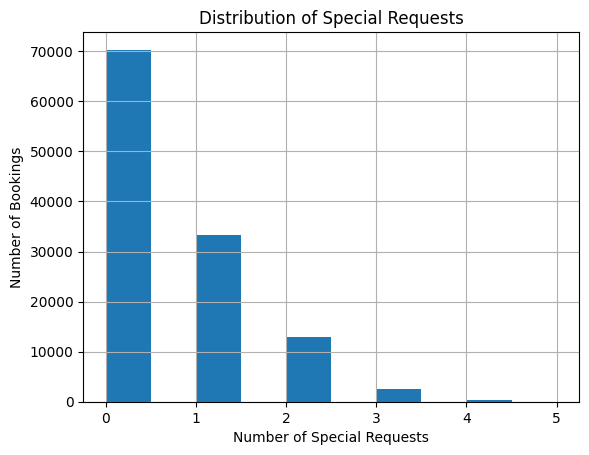

In [ ]:
# Discovery Angle 3: Special Requests and Cancellations
df.groupby("is_canceled")["total_of_special_requests"].mean()
df["total_of_special_requests"].hist()

plt.title("Distribution of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Number of Bookings")

plt.show()

**Finding 3:**

Guests who make special requests tend to cancel less often. This may indicate that travelers who take the time to customize their stay are more committed to their reservation. Encouraging guests to personalize their stay could potentially reduce cancellation rates.



---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [ ]:
# Data preparation
# Define the target variable
y = df["is_canceled"]
# Select features based on the exploration
features = df[[
    "lead_time",
    "adr",
    "total_of_special_requests",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "adults",
    "children",
    "hotel"
]]
# Convert categorical variables to numbers
features = pd.get_dummies(features, drop_first=True)
# Handle missing values (fill with 0)
features = features.fillna(0)
# Create the feature matrix
X = features

**Why these features?**

The features were selected based on patterns observed during the exploratory analysis. Factors such as lead time, room price (ADR), number of special requests, and length of stay showed noticeable differences between canceled and completed bookings, suggesting they may influence whether a reservation is canceled. Guest characteristics like the number of adults and children, along with hotel type, were also included because they may reflect different travel behaviors that affect cancellation likelihood.


### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

Accuracy: 0.6811290727866656


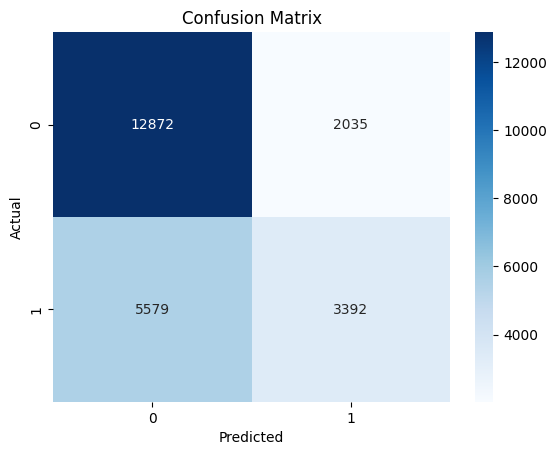

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Your model code here
# Split the data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create the Gaussian Naive Bayes model
model = GaussianNB()
# Train the model
model.fit(X_train, y_train)
# Generate predictions
y_pred = model.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

> *"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."*

**Model Performance — Business Translation:**

The model correctly predicts the outcome of bookings about 68% of the time, meaning it can reasonably distinguish between reservations that will be canceled and those that will not. However, the confusion matrix shows that some cancellations are still missed so the hotel may not always identify guests who will cancel in advance. Missing these cancellations could lead to empty rooms and lost of revenue if the hotel is unable to refill those bookings.

The model also occasionally flags bookings as potential cancellations when they are actually confirmed, which could result in unnecessary follow-up emails or calls. The cost of these extra follow-ups is likely smaller than the potential revenue loss from missed cancellations, suggesting the model could provide useful guidance for managing bookings more effectively.



### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

Logistic Regression Accuracy: 0.6981321718736913


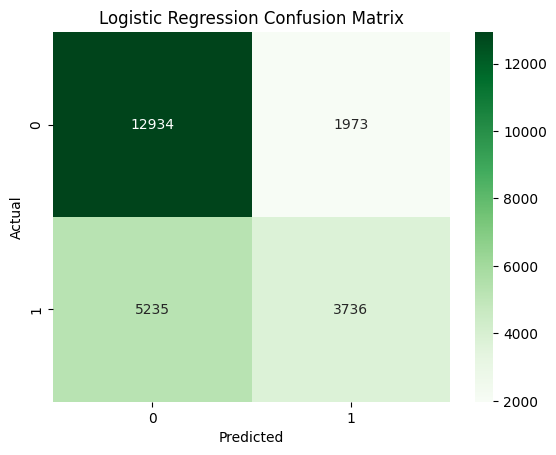

In [ ]:
# Optional: Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_predictions)
print("Logistic Regression Accuracy:", log_accuracy)

log_cm = confusion_matrix(y_test, log_predictions)

sns.heatmap(log_cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

**Recommendations for Portugal Hotel Chain:**

**1. Implement automated reminder emails for bookings made far in advance -
The hotel should implement automated reminder emails or confirmation requests for guests who book their stays far in advance, such as 30–60 days before arrival. The analysis showed that reservations with longer lead times were more likely to be canceled than bookings made closer to the stay date. Encouraging guests to confirm their plans earlier could help identify cancellations sooner and allow the hotel to resell those rooms. If reminder emails reduce cancellations by even 10–15%, the hotel could recover revenue that would otherwise be lost from last-minute cancellations.

**2. Encourage guests to personalize their reservation with special requests -
The hotel should also encourage guests to personalize their reservations by adding special requests during the booking process, such as preferred room location, amenities, or early check-in options. The data showed that guests who made special requests were less likely to cancel their reservations, suggesting that travelers who engage more with their booking are more committed to their stay. Prompting guests to add preferences during booking could strengthen this engagement. Increasing personalization could reduce cancellations by approximately 5–10%, helping improve overall occupancy rates.


**3. Adjust policies for lower-priced or flexible bookings -
The hotel should review pricing or deposit policies for lower-priced or highly flexible bookings. The exploratory analysis suggested that lower-priced reservations were slightly more likely to be canceled, indicating that guests choosing these options may be less committed to their stay. Introducing small deposits or offering incentives for non-refundable bookings could encourage guests to keep their reservations. Even a 5–10% reduction in cancellations among these bookings could help stabilize revenue and improve room utilization during high-demand periods.

---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [27]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
Empty Rooms, Lost Revenue: Predicting Hotel Booking Cancellations

Using booking data to predict which reservations are most likely to cancel so hotels can minimize lost revenue and plan occupancy more effectively.


The Business Problem

Last-minute booking cancellations are a major challenge for hotels. When guests cancel close to their arrival date, it can be difficult to refill those rooms in time, leading to lost revenue and unnecessary operational stress. By understanding which reservations are more likely to cancel, hotels can take proactive steps—such as sending reminders or adjusting booking policies—to reduce cancellations and better manage occupancy.

The Data

This analysis uses the Hotel Booking Demand dataset, which includes information from over 119,000 hotel reservations. The data captures details such as how far in advance guests booked, room prices, length of stay, and basic guest information. By looking at patterns across these bookings, we can better understand what factors are associated with cancellations.

Key Discoveries

- More Than 1 in 3 Hotel Bookings End in Cancellation: Out of 119,390 reservations, roughly 37% were canceled, highlighting how common cancellations are and why predicting them is critical for protecting hotel revenue.
- Guests Who Book Months Ahead Are More Likely to Cancel: Bookings made far in advance showed noticeably higher cancellation rates compared to reservations made closer to the stay date, suggesting long-term travel plans are more likely to change.
- Guests Who Add Special Requests Are Less Likely to Cancel: Guests who included special requests—such as room preferences or amenities—were less likely to cancel their reservation, indicating that travelers who engage more with their booking tend to be more committed to their stay.
- Budget Bookings Show Slightly Higher Cancellation Risk: Lower-priced reservations showed somewhat higher cancellation rates, suggesting that guests choosing cheaper or more flexible options may be less committed to their booking.

Visualizing the Story

![Room Price by Cancellation](room_price_by_cancellation.png)

*[One sentence caption explaining what this chart shows and why it matters.]*

## Prediction Model

[2-3 sentences. How well can we predict the outcome? Translate accuracy into real-world terms.]

<!--
Tip: Translate model metrics into business impact.
Instead of "The model achieved 78% accuracy..."
Try: "Our model correctly flags 8 out of 10 at-risk bookings, giving the hotel front desk team
enough lead time to proactively reach out and offer flexible rebooking options."
-->

## Recommendations

1. **[Action]:** [Why this action, based on your data. Estimated impact.]
2. **[Action]:** [Why this action, based on your data. Estimated impact.]
3. **[Action]:** [Why this action, based on your data. Estimated impact.]

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)


Empty Rooms, Lost Revenue: Predicting Hotel Booking Cancellations

Using booking data to predict which reservations are most likely to cancel so hotels can minimize lost revenue and plan occupancy more effectively.


The Business Problem

Last-minute booking cancellations are a major challenge for hotels. When guests cancel close to their arrival date, it can be difficult to refill those rooms in time, leading to lost revenue and unnecessary operational stress. By understanding which reservations are more likely to cancel, hotels can take proactive steps—such as sending reminders or adjusting booking policies—to reduce cancellations and better manage occupancy.

The Data

This analysis uses the Hotel Booking Demand dataset, which includes information from over 119,000 hotel reservations. The data captures details such as how far in advance guests booked, room prices, length of stay, and basic guest information. By looking at patterns across these bookings, we can better understand wha

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*